In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.7,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [5]:
Y.mean(), Y.std()

(np.float64(0.37785301213296585), np.float64(2.056099615162873))

In [6]:
Y_test.mean(), Y_test.std()

(np.float64(0.2547040510670968), np.float64(1.8803696674527284))

In [7]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [8]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=torch.float32), 
        torch.tensor(Y, dtype=torch.float32)
        ), 
    batch_size = 8, 
    shuffle = True)

In [9]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

## Model & Training

In [10]:
model = nft.rule_reduced_ANFIS(
    input_size = 2,
    num_mfs = 6,
    outputs = 1,
    dtype = x_train.dtype
)

In [11]:
model.init_premises(x_train)

In [12]:
model.show_premises_structure()

      a (x0)  b (x0)  c (x0)  a (x1)  b (x1)  c (x1)
MF 0     0.2     4.0    -1.0     0.2     4.0    -1.0
MF 1     0.2     4.0    -0.6     0.2     4.0    -0.6
MF 2     0.2     4.0    -0.2     0.2     4.0    -0.2
MF 3     0.2     4.0     0.2     0.2     4.0     0.2
MF 4     0.2     4.0     0.6     0.2     4.0     0.6
MF 5     0.2     4.0     1.0     0.2     4.0     1.0


In [13]:
model.get_premises()

tensor([[[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]],

        [[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]]])

In [14]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = nft.EarlyStopping(patience=30)

trainer = nft.Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [15]:
trainer(model, train_loader, verbose=True)

Epoch:   1/500 - loss: 2.125419 - validation loss: 2.404606
Epoch:   2/500 - loss: 2.052567 - validation loss: 2.361805
Epoch:   3/500 - loss: 1.980380 - validation loss: 2.323098
Epoch:   4/500 - loss: 1.916512 - validation loss: 2.289281
Epoch:   5/500 - loss: 1.859083 - validation loss: 2.259858
Epoch:   6/500 - loss: 1.807591 - validation loss: 2.231294
Epoch:   7/500 - loss: 1.763677 - validation loss: 2.209236
Epoch:   8/500 - loss: 1.726158 - validation loss: 2.185992
Epoch:   9/500 - loss: 1.692904 - validation loss: 2.167833
Epoch:  10/500 - loss: 1.665201 - validation loss: 2.151857
Epoch:  11/500 - loss: 1.640528 - validation loss: 2.135275
Epoch:  12/500 - loss: 1.619363 - validation loss: 2.124391
Epoch:  13/500 - loss: 1.600826 - validation loss: 2.108144
Epoch:  14/500 - loss: 1.580606 - validation loss: 2.093987
Epoch:  15/500 - loss: 1.562681 - validation loss: 2.078416
Epoch:  16/500 - loss: 1.544515 - validation loss: 2.065788
Epoch:  17/500 - loss: 1.526481 - valida

In [16]:
model.show_premises_structure()

        a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
MF 0  0.317495  3.845184 -0.895296  0.326445  3.700677 -1.035007
MF 1  0.235305  3.926414 -0.522064  0.245460  3.888952 -0.765529
MF 2  0.122804  4.006909 -0.065257  0.186614  4.005844 -0.317666
MF 3  0.178758  3.827093  0.007251  0.162612  3.919221  0.170608
MF 4  0.173714  4.264091  0.458659  0.221390  4.001564  0.459584
MF 5  0.277549  3.921040  0.850037  0.321708  3.700324  1.038736


In [17]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.317495,3.845184,-0.895296,0.326445,3.700677,-1.035007
MF 1,0.235305,3.926414,-0.522064,0.245460,3.888952,-0.765529
MF 2,0.122804,4.006909,-0.065257,0.186614,4.005844,-0.317666
MF 3,0.178758,3.827093,0.007251,0.162612,3.919221,0.170608
MF 4,0.173714,4.264091,0.458659,0.221390,4.001564,0.459584
MF 5,0.277549,3.921040,0.850037,0.321708,3.700324,1.038736


In [18]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.48975861072540283
RMSE: 0.6998275518417358
MAE: 0.46536925435066223
R2: 0.8614853620529175
MAPE: 48.91963195800781


In [19]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.8238434791564941
RMSE: 0.9076582193374634
MAE: 0.719557523727417
R2: 0.8051248788833618
MAPE: 2.0375659465789795


In [20]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.317495,3.845184,-0.895296,0.326445,3.700677,-1.035007
MF 1,0.235305,3.926414,-0.522064,0.245460,3.888952,-0.765529
MF 2,0.122804,4.006909,-0.065257,0.186614,4.005844,-0.317666
MF 3,0.178758,3.827093,0.007251,0.162612,3.919221,0.170608
MF 4,0.173714,4.264091,0.458659,0.221390,4.001564,0.459584
MF 5,0.277549,3.921040,0.850037,0.321708,3.700324,1.038736


In [21]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,0.930590,0.102112,0.766810
rule 2,-3.303780,-2.779300,-3.421401
rule 3,-7.400438,18.775635,5.466726
rule 4,7.094331,13.095533,-0.884043
rule 5,-8.134886,-1.855691,6.640191
rule 6,-0.473907,-0.195809,0.569275


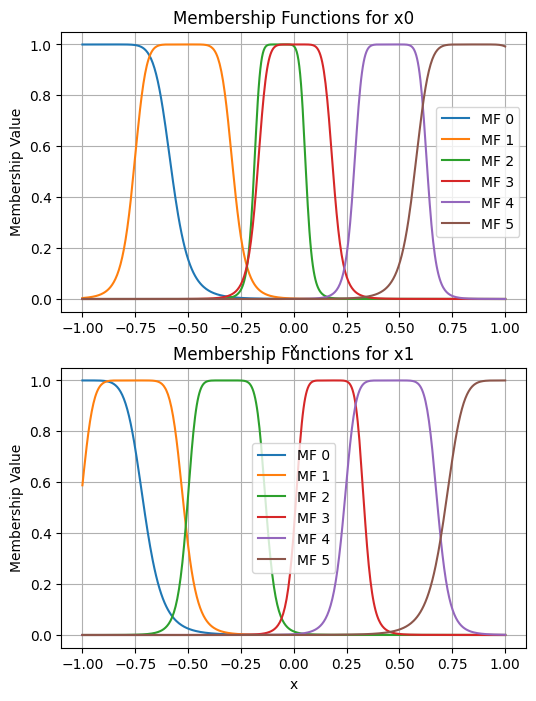

In [22]:
model.plot_premises(group_by_dim=True)